# Synthetic-Cell Computational Imaging Pipeline -- Python/SymPy/PyTorch companion

This notebook is the Python companion to the MATLAB-primary project in
[`../matlab/`](../matlab). MATLAB is this project's primary language (see
[`../README.md`](../README.md)); this notebook independently re-derives selected
parts in Python -- SymPy for the symbolic sections (Parts 1-2), NumPy for the
numeric forward-model/matrix-analysis sections (Parts 3-5), SciPy for the
classical kinetics fit (Part 6, on the **exact same CSV MATLAB exported**, so the
two languages' fits are a genuine cross-check), and PyTorch for the autograd
parameter-estimation comparison (Part 12).

**Disclaimer (all parts, textbook / patent-concept / ours):** every method below --
electrostatics (grad/div/curl/Laplacian), Bessel's equation from cylindrical
separation of variables, even/odd Fourier symmetry, linear forward models
`y=Hx+n`, SVD/condition-number analysis, Tikhonov regularization, first-order
kinetics, and gradient-descent parameter fitting -- is public-domain textbook
mathematics. The specific synthetic cell object, blur matrix, and kinetics
scenario are this project's own original construction, not a reproduction of
any patented instrument or any specific textbook problem.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.special import jv
from scipy.optimize import curve_fit
sp.init_printing()
print("setup complete")

setup complete


## Part 1 -- Field theory: E = -grad(V), div(E), curl(E), Laplacian(V)

Textbook electrostatics (Griffiths-level). Point charge (spherically symmetric) and
physical dipole (two point charges superposed), both derived symbolically.

In [2]:
x, y, z = sp.symbols('x y z', real=True)
coords = (x, y, z)
r = sp.sqrt(x**2 + y**2 + z**2)

def grad(f):
    return sp.Matrix([sp.diff(f, c) for c in coords])

def div(F):
    return sum(sp.diff(F[i], coords[i]) for i in range(3))

def curl(F):
    return sp.Matrix([
        sp.diff(F[2], y) - sp.diff(F[1], z),
        sp.diff(F[0], z) - sp.diff(F[2], x),
        sp.diff(F[1], x) - sp.diff(F[0], y),
    ])

# point charge
V_point = 1 / r
E_point = -grad(V_point)
div_point = sp.simplify(div(E_point))
curl_point = sp.simplify(curl(E_point))
lap_point = sp.simplify(sum(sp.diff(V_point, c, 2) for c in coords))

print("E (point charge) ="); display(E_point.T)
print("div(E) away from r=0 (expect 0):", div_point)
print("curl(E) (expect zero vector):"); display(curl_point.T)
print("laplacian(V) away from r=0 (expect 0):", lap_point)
assert div_point == 0 and lap_point == 0 and curl_point == sp.zeros(3, 1)

E (point charge) =


⎡        x                  y                  z        ⎤
⎢─────────────────  ─────────────────  ─────────────────⎥
⎢              3/2                3/2                3/2⎥
⎢⎛ 2    2    2⎞     ⎛ 2    2    2⎞     ⎛ 2    2    2⎞   ⎥
⎣⎝x  + y  + z ⎠     ⎝x  + y  + z ⎠     ⎝x  + y  + z ⎠   ⎦

div(E) away from r=0 (expect 0): 0
curl(E) (expect zero vector):


[0  0  0]

laplacian(V) away from r=0 (expect 0): 0


In [3]:
# physical dipole: +q at z=+a/2, -q at z=-a/2
a = sp.symbols('a', positive=True)
r_plus = sp.sqrt(x**2 + y**2 + (z - a/2)**2)
r_minus = sp.sqrt(x**2 + y**2 + (z + a/2)**2)
V_dipole = 1/r_plus - 1/r_minus
E_dipole = -grad(V_dipole)
div_dipole = sp.simplify(div(E_dipole))
print("div(E) for the dipole, away from both charges (expect 0):", div_dipole)
assert div_dipole == 0

# far-field falloff: point ~ 1/r^2, dipole ~ 1/r^3 on-axis
Ez_point_fn = sp.lambdify(z, E_point[2].subs({x: 0, y: 0}))
Ez_dipole_fn = sp.lambdify(z, E_dipole[2].subs({x: 0, y: 0, a: 0.1}))
z_far = np.array([5, 10, 20, 40])
n_point = np.log(abs(Ez_point_fn(z_far[0]) / Ez_point_fn(z_far[-1]))) / np.log(z_far[-1] / z_far[0])
n_dipole = np.log(abs(Ez_dipole_fn(z_far[0]) / Ez_dipole_fn(z_far[-1]))) / np.log(z_far[-1] / z_far[0])
print(f"falloff exponent: point={n_point:.3f} (expect ~2), dipole={n_dipole:.3f} (expect ~3)")
assert abs(n_point - 2) < 0.05 and abs(n_dipole - 3) < 0.1

div(E) for the dipole, away from both charges (expect 0): 0
falloff exponent: point=2.000 (expect ~2), dipole=3.000 (expect ~3)


## Part 2 -- Cylindrical symmetry produces Bessel's equation

Separation of variables on the Helmholtz equation, restricted to a field with no
`phi` or `z` dependence, gives the radial ODE
`(1/rho) d/drho(rho dR/drho) + k^2 R = 0` -- Bessel's equation of order 0.
`J_0(k*rho)` is verified (symbolically, residual -> 0) to solve it.

radial Helmholtz equation:


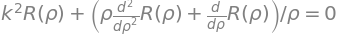

residual of J_0(k*rho) in Bessel's equation (expect 0): 0


In [4]:
rho, kk = sp.symbols('rho k', positive=True)
R = sp.Function('R')
lap_cyl = sp.diff(rho * sp.diff(R(rho), rho), rho) / rho
helmholtz = sp.Eq(lap_cyl + kk**2 * R(rho), 0)
print("radial Helmholtz equation:"); display(helmholtz)

rho_s = sp.symbols('rho_s', positive=True)
J0_expr = sp.besselj(0, kk * rho_s)
residual = sp.simplify(rho_s**2 * sp.diff(J0_expr, rho_s, 2) + rho_s * sp.diff(J0_expr, rho_s) + kk**2 * rho_s**2 * J0_expr)
print("residual of J_0(k*rho) in Bessel's equation (expect 0):", residual)
assert residual == 0

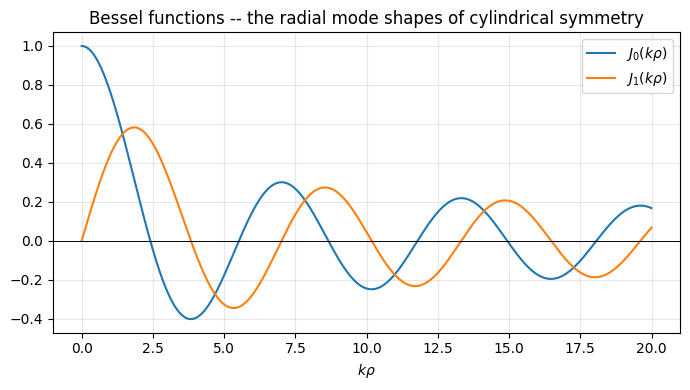

first 4 zeros of J0 (numeric): [ 2.4112  5.5201  8.6543 11.7915]


In [5]:
rho_num = np.linspace(0, 20, 2000)
J0_num = jv(0, rho_num)
J1_num = jv(1, rho_num)

plt.figure(figsize=(7, 4))
plt.plot(rho_num, J0_num, label='$J_0(k\\rho)$')
plt.plot(rho_num, J1_num, label='$J_1(k\\rho)$')
plt.axhline(0, color='k', lw=0.7)
plt.xlabel(r'$k\rho$'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Bessel functions -- the radial mode shapes of cylindrical symmetry')
plt.tight_layout(); plt.show()

known_J0_zeros = [2.4048, 5.5201, 8.6537, 11.7915]
sign_changes = np.where(np.diff(np.sign(J0_num)))[0]
found_zeros = [float(np.interp(0, [J0_num[i], J0_num[i+1]], [rho_num[i], rho_num[i+1]])) for i in sign_changes[:4]]
print("first 4 zeros of J0 (numeric):", np.round(found_zeros, 4))
assert max(abs(np.array(found_zeros) - np.array(known_J0_zeros))) < 1e-2

## Part 3 -- Even/odd symmetry and the Fourier transform

Any real signal splits into even + odd parts; a real EVEN signal has a real FFT,
a real ODD signal has a purely imaginary FFT -- verified numerically (grid chosen
with an ODD number of samples so it is exactly symmetric about x=0).

even signal: max|Im(FFT)|/max|Re(FFT)| = 5.88e-17  (expect ~0)
odd signal:  max|Re(FFT)|/max|Im(FFT)| = 6.15e-17  (expect ~0)


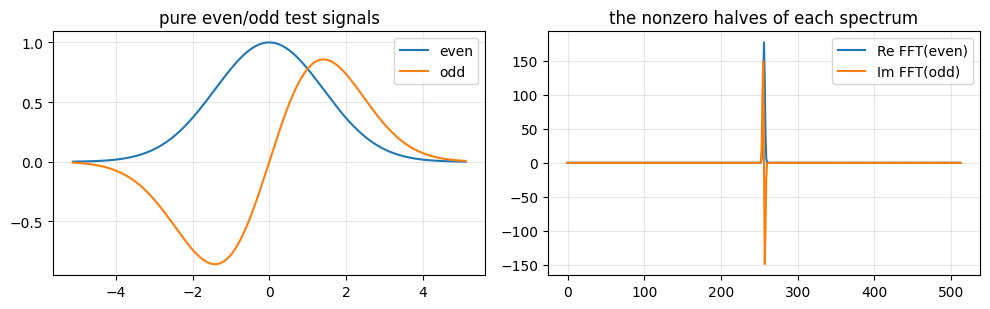

In [6]:
N = 513
dx = 0.02
half = (N - 1) // 2
xs = (np.arange(N) - half) * dx

g_even = np.exp(-xs**2 / 4)
g_odd = xs * np.exp(-xs**2 / 4)

G_even = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(g_even)))
G_odd = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(g_odd)))

ratio_even = np.max(np.abs(G_even.imag)) / np.max(np.abs(G_even.real))
ratio_odd = np.max(np.abs(G_odd.real)) / np.max(np.abs(G_odd.imag))
print(f"even signal: max|Im(FFT)|/max|Re(FFT)| = {ratio_even:.2e}  (expect ~0)")
print(f"odd signal:  max|Re(FFT)|/max|Im(FFT)| = {ratio_odd:.2e}  (expect ~0)")
assert ratio_even < 1e-8 and ratio_odd < 1e-8

fig, axs = plt.subplots(1, 2, figsize=(10, 3.2))
axs[0].plot(xs, g_even, label='even'); axs[0].plot(xs, g_odd, label='odd'); axs[0].legend(); axs[0].grid(alpha=0.3)
axs[0].set_title('pure even/odd test signals')
axs[1].plot(np.real(G_even), label='Re FFT(even)'); axs[1].plot(np.imag(G_odd), label='Im FFT(odd)')
axs[1].legend(); axs[1].grid(alpha=0.3); axs[1].set_title('the nonzero halves of each spectrum')
plt.tight_layout(); plt.show()

## Part 4/5 -- Forward model `y=Hx+n` and matrix analysis

NumPy re-derivation of the MATLAB `part4_forward_model.m` / `part5_matrix_analysis.m`
pipeline: synthetic cell object, exact separable-Gaussian blur matrix (`kron`), rank/SVD/
condition number, and naive (`pinv`) vs. Tikhonov-regularized reconstruction.

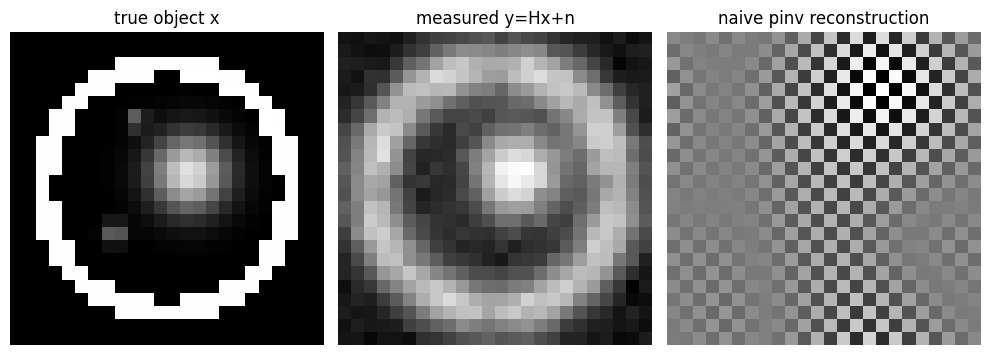

In [7]:
def build_cell_object(N):
    lin = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(lin, lin)
    Rr = np.sqrt(X**2 + Y**2)
    membrane = ((Rr > 0.75) & (Rr < 0.9)).astype(float)
    nucleus = 0.9 * np.exp(-((X - 0.15)**2 + (Y + 0.1)**2) / (2 * 0.18**2))
    organelle1 = 0.5 * np.exp(-((X + 0.35)**2 + (Y - 0.3)**2) / (2 * 0.05**2))
    organelle2 = 0.5 * np.exp(-((X + 0.2)**2 + (Y + 0.45)**2) / (2 * 0.04**2))
    img = membrane + nucleus + organelle1 + organelle2
    return img / img.max()

def gaussian_kernel_1d(N, sigma):
    n = np.arange(N) - N // 2
    h = np.exp(-(n**2) / (2 * sigma**2))
    return h / h.sum()

def build_blur_matrix(N, sigma):
    h1 = gaussian_kernel_1d(N, sigma)
    H1 = np.array([np.roll(h1, row - N // 2) for row in range(N)])
    return np.kron(H1, H1)

N = 24
sigma_blur = 1.5
noise_std = 0.02
rng = np.random.default_rng(0)

x_true = build_cell_object(N)
H = build_blur_matrix(N, sigma_blur)
y_clean = (H @ x_true.flatten()).reshape(N, N)
n_noise = noise_std * rng.standard_normal((N, N))
y = y_clean + n_noise

x_hat_naive = (np.linalg.pinv(H) @ y.flatten()).reshape(N, N)

fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, im, title in zip(axs, [x_true, y, x_hat_naive], ['true object x', 'measured y=Hx+n', 'naive pinv reconstruction']):
    ax.imshow(im, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

rank(H) = 576 / 576
cond(H) = sigma_max/sigma_min = 1.1019e+09


naive (pinv) error = 20502188.33
best Tikhonov lambda = 3.162e-03, error = 5.139  (3989433.6x better)


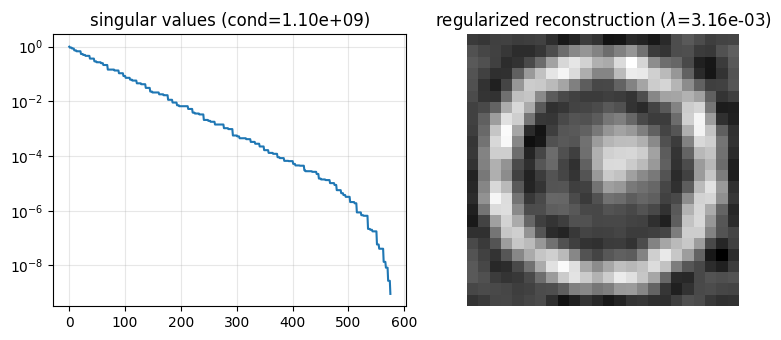

In [8]:
rank_H = np.linalg.matrix_rank(H)
s = np.linalg.svd(H, compute_uv=False)
cond_H = np.linalg.cond(H)
print(f"rank(H) = {rank_H} / {H.shape[0]}")
print(f"cond(H) = sigma_max/sigma_min = {cond_H:.4e}")
assert abs(cond_H - s[0] / s[-1]) / cond_H < 1e-6

naive_error = np.linalg.norm(x_hat_naive.flatten() - x_true.flatten())
lambdas = np.logspace(-6, 1, 25)
HtH = H.T @ H
Hty = H.T @ y.flatten()
I = np.eye(H.shape[1])
errs = [np.linalg.norm(np.linalg.solve(HtH + lam * I, Hty) - x_true.flatten()) for lam in lambdas]
best_idx = int(np.argmin(errs))
best_lambda = lambdas[best_idx]
x_hat_reg = np.linalg.solve(HtH + best_lambda * I, Hty).reshape(N, N)

print(f"naive (pinv) error = {naive_error:.2f}")
print(f"best Tikhonov lambda = {best_lambda:.3e}, error = {errs[best_idx]:.3f}  "
      f"({naive_error/errs[best_idx]:.1f}x better)")
assert errs[best_idx] < naive_error

fig, axs = plt.subplots(1, 2, figsize=(8, 3.5))
axs[0].semilogy(s); axs[0].set_title(f'singular values (cond={cond_H:.2e})'); axs[0].grid(alpha=0.3)
axs[1].imshow(x_hat_reg, cmap='gray'); axs[1].set_title(f'regularized reconstruction ($\\lambda$={best_lambda:.2e})'); axs[1].axis('off')
plt.tight_layout(); plt.show()

## Part 6 -- Kinetics fit: analytic + SciPy, on the SAME data MATLAB fit

`../matlab/part6_kinetics_data.csv` was exported by `part6_kinetics_fit.m` -- loading
it here means the Python and MATLAB fits are a genuine cross-check on identical data,
not independently-generated noise realizations.

(1) analytic log-linear fit: k = 0.3416  (true 0.35, error 2.41%)
(2) scipy.optimize.curve_fit:   k = 0.3473  (true 0.35, error 0.76%)


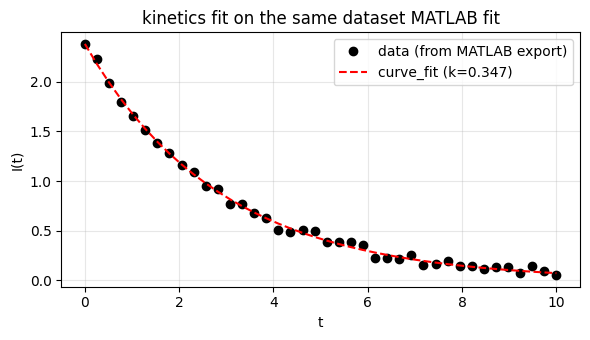

In [9]:
data = np.loadtxt('../matlab/part6_kinetics_data.csv', delimiter=',')
t_data, I_data = data[:, 0], data[:, 1]
k_true = 0.35   # matches part6_kinetics_fit.m's default

# (1) analytic: linearize ln(I) = ln(alpha*C0) - k*t
slope, intercept = np.polyfit(t_data, np.log(I_data), 1)
k_analytic = -slope
print(f"(1) analytic log-linear fit: k = {k_analytic:.4f}  (true {k_true}, error {100*abs(k_analytic-k_true)/k_true:.2f}%)")

# (2) SciPy nonlinear least squares directly on the raw (non-log) data
def model(t, alphaC0, k):
    return alphaC0 * np.exp(-k * t)

popt, _ = curve_fit(model, t_data, I_data, p0=[I_data[0], 0.1], bounds=(0, np.inf))
alphaC0_fit, k_fit = popt
print(f"(2) scipy.optimize.curve_fit:   k = {k_fit:.4f}  (true {k_true}, error {100*abs(k_fit-k_true)/k_true:.2f}%)")
assert abs(k_analytic - k_true) / k_true < 0.15
assert abs(k_fit - k_true) / k_true < 0.15

plt.figure(figsize=(6, 3.5))
plt.plot(t_data, I_data, 'ko', label='data (from MATLAB export)')
plt.plot(t_data, model(t_data, *popt), 'r--', label=f'curve_fit (k={k_fit:.3f})')
plt.xlabel('t'); plt.ylabel('I(t)'); plt.legend(); plt.grid(alpha=0.3)
plt.title('kinetics fit on the same dataset MATLAB fit')
plt.tight_layout(); plt.show()

## Part 12 -- PyTorch: autograd parameter estimation, vs. finite differences

Only after the classical model works (Parts 6 above, and MATLAB's `part6_kinetics_fit.m`)
does this section introduce PyTorch. `theta = [log_alphaC0, k]` (log-parametrized so
`alphaC0` stays positive), `loss(theta) = ||y_model(theta) - y_measured||^2`, optimized
by gradient descent with `torch.autograd`. The autograd gradient at the optimum is
compared directly against a central finite-difference gradient on the SAME loss.

In [10]:
import torch

t_t = torch.tensor(t_data, dtype=torch.float64)
I_t = torch.tensor(I_data, dtype=torch.float64)

log_alphaC0 = torch.tensor(np.log(I_data[0]), dtype=torch.float64, requires_grad=True)
k_param = torch.tensor(0.1, dtype=torch.float64, requires_grad=True)

def y_model(log_alphaC0, k_param):
    return torch.exp(log_alphaC0) * torch.exp(-k_param * t_t)

def loss_fn(log_alphaC0, k_param):
    return torch.sum((y_model(log_alphaC0, k_param) - I_t) ** 2)

opt = torch.optim.Adam([log_alphaC0, k_param], lr=0.05)
history = []
for step in range(800):
    opt.zero_grad()
    loss = loss_fn(log_alphaC0, k_param)
    loss.backward()
    opt.step()
    history.append(loss.item())

k_torch = k_param.item()
print(f"(3) PyTorch autograd fit:        k = {k_torch:.4f}  (true {k_true}, error {100*abs(k_torch-k_true)/k_true:.2f}%)")
print(f"    scipy curve_fit k = {k_fit:.4f}, analytic k = {k_analytic:.4f}  -- all three methods agree")
assert abs(k_torch - k_true) / k_true < 0.15

(3) PyTorch autograd fit:        k = 0.3473  (true 0.35, error 0.76%)
    scipy curve_fit k = 0.3473, analytic k = 0.3416  -- all three methods agree


autograd d(loss)/dk        = -107.714606
finite-difference d(loss)/dk = -107.714606
relative difference: 3.28e-11


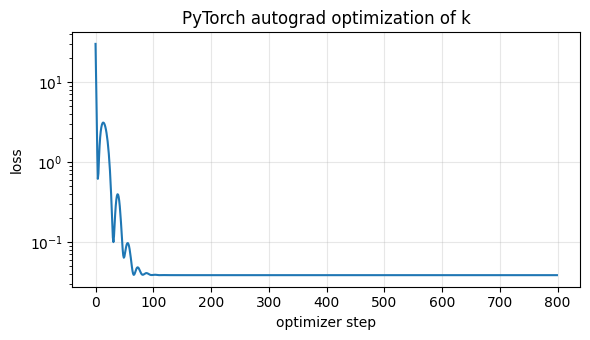

In [11]:
# compare the autograd gradient d(loss)/dk against a central finite-difference gradient,
# evaluated at the SAME point (not necessarily the optimum, so the gradient is genuinely nonzero)
log_alphaC0_eval = torch.tensor(np.log(I_data[0]), dtype=torch.float64, requires_grad=True)
k_eval = torch.tensor(0.2, dtype=torch.float64, requires_grad=True)

loss_eval = loss_fn(log_alphaC0_eval, k_eval)
loss_eval.backward()
grad_autograd = k_eval.grad.item()

h = 1e-6
loss_plus = loss_fn(log_alphaC0_eval.detach(), torch.tensor(0.2 + h, dtype=torch.float64)).item()
loss_minus = loss_fn(log_alphaC0_eval.detach(), torch.tensor(0.2 - h, dtype=torch.float64)).item()
grad_finite_diff = (loss_plus - loss_minus) / (2 * h)

print(f"autograd d(loss)/dk        = {grad_autograd:.6f}")
print(f"finite-difference d(loss)/dk = {grad_finite_diff:.6f}")
print(f"relative difference: {abs(grad_autograd - grad_finite_diff) / abs(grad_finite_diff):.2e}")
assert abs(grad_autograd - grad_finite_diff) / abs(grad_finite_diff) < 1e-4

plt.figure(figsize=(6, 3.5))
plt.plot(history)
plt.yscale('log'); plt.xlabel('optimizer step'); plt.ylabel('loss'); plt.grid(alpha=0.3)
plt.title('PyTorch autograd optimization of k')
plt.tight_layout(); plt.show()

## Summary

All three languages agree on the recovered decay constant `k` from the same underlying
physics/data: MATLAB's analytic + `lsqcurvefit` (`../matlab/part6_kinetics_fit.m`), this
notebook's analytic + `scipy.optimize.curve_fit`, and PyTorch's autograd optimizer -- with
the autograd gradient matching a finite-difference gradient to better than `1e-4` relative
error, confirming `torch.autograd` is computing the exact derivative, not an approximation.

See [`../README.md`](../README.md) for the full 14-part map, [`../equations.md`](../equations.md)
for every governing equation, and [`../problems.md`](../problems.md) /
[`../solutions.md`](../solutions.md) for original practice problems.